In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import zipfile
import os

In [5]:
# Download the 4 csv physical data

df_1 = pd.read_csv('data/dataset/Physical dataset/cleaned/phy_att_1_cleaned.csv', delimiter=',', header=0, encoding='utf-8')
df_2 = pd.read_csv('data/dataset/Physical dataset/cleaned/phy_att_2_cleaned.csv', delimiter=',', header=0, encoding='utf-8')
df_3 = pd.read_csv('data/dataset/Physical dataset/cleaned/phy_att_3_cleaned.csv', delimiter=',', header=0, encoding='utf-8')
df_4 = pd.read_csv('data/dataset/Physical dataset/cleaned/phy_att_4_cleaned.csv', delimiter=',', header=0, encoding='utf-8')

In [6]:
# Remove Pump_3 column and Valv_1 to Valv_9 columns, because they are all set to False

columns_to_remove = ['Time','Pump_3', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4', 'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9']

df_1 = df_1.drop(columns=columns_to_remove)
df_2 = df_2.drop(columns=columns_to_remove)
df_3 = df_3.drop(columns=columns_to_remove)
df_4 = df_4.drop(columns=columns_to_remove)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import pandas as pd
import plotly.express as px
import numpy as np
import time

df = df_4

features = df.drop(['Label', 'Label_n'], axis=1)
target = df['Label']

# Normalize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features_scaled, target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

results = []  # To store the results
confusion_matrices = {}  # to store the confusion matrices

for k in range(1, 51):  # De k=1 à k=50
    knn = KNeighborsClassifier(n_neighbors=k)

    start_time = time.time()
    knn.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({"k": k, "accuracy": accuracy, "training_time": training_time})
    confusion_matrices[k] = cm

# Convertir les résultats en DataFrame pour l'analyse dans Streamlit
results_df = pd.DataFrame(results)

# Affichage des résultats sous forme de graphique (exemple pour la précision)
fig = px.line(
    results_df,
    x="k",
    y="accuracy",
    title="Précision en fonction de k (KNN)",
    labels={"k": "Nombre de voisins (k)", "accuracy": "Précision"},
    markers=True,
)
fig.show()

# Save the img

if not os.path.exists("data/results/figures"):
    os.makedirs("data/results/figures")

fig.write_image("data/results/figures/knn_accuracy_df_4.png")

In [19]:
# Affichage d'une matrice de confusion spécifique (exemple pour k=5)
selected_k = 5
if selected_k in confusion_matrices:
    cm = confusion_matrices[selected_k]
    fig_cm = px.imshow(
        cm,
        text_auto=".2f",
        color_continuous_scale="rdylbu",
        labels=dict(x="Predicted", y="True", color="Count"),
        title=f"Matrice de confusion pour k={selected_k}",
    )
    fig_cm.show()

# Save the img for k=5
fig_cm.write_image("data/results/figures/knn_cm_df_4.png")

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.95      0.89       322
        True       0.86      0.61      0.71       162

    accuracy                           0.84       484
   macro avg       0.85      0.78      0.80       484
weighted avg       0.84      0.84      0.83       484

Balanced Accuracy: 0.78
F1-Score: 0.71
MCC: 0.62


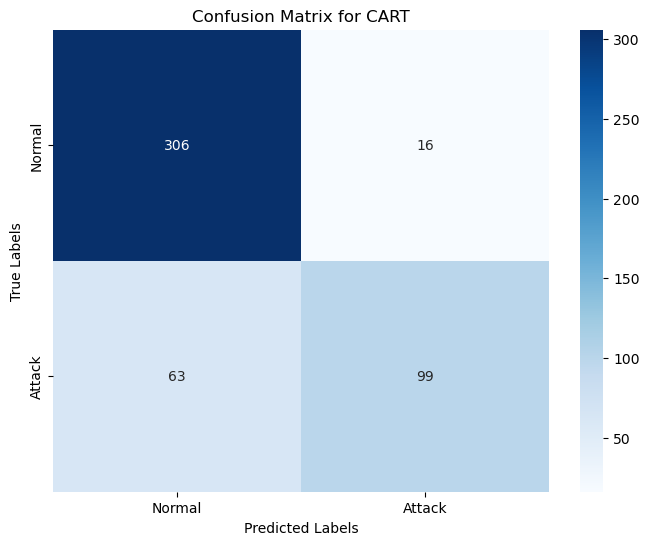

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, balanced_accuracy_score, matthews_corrcoef
)
import seaborn as sns
import matplotlib.pyplot as plt

# Diviser les données en caractéristiques (X) et cible (y)
X = df_1.drop(columns=['Label_n', 'Label'])  # Features
y = df_1['Label']  # Target (0 ou 1)

# Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Créer et entraîner le modèle CART
cart_model = DecisionTreeClassifier(random_state=42, max_depth=5)
cart_model.fit(X_train, y_train)

# Prédictions
y_pred = cart_model.predict(X_test)

# Évaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix for CART')
plt.show()